## Observations

In [2]:
# import packages
import sys
import os
from dotenv import load_dotenv
from IPython.display import display, HTML
import json
import matplotlib.pyplot as plt
import folium

# Load environment variables from .env file
load_dotenv()

# import the API builder
sys.path.append(os.path.abspath(".."))
from scoutmasterapi_builder.api import ScoutMasterAPI

In [5]:
# Scoutmaster API - Credentials
client_id = os.getenv('SM_CLIENT_ID')
client_secret = os.getenv('SM_CLIENT_SECRET')
project_id = "c52cc8b0-fd2e-4d7b-bc73-9623f8f212ae"
dev = os.getenv("DEV") == "True"

# Scoutmaster API - Init
SM_API = ScoutMasterAPI(dev, version="v3")
SM_API.authenticate(client_id=client_id, client_secret=client_secret)

Initialized ScoutMaster API with host: https://api.scoutmaster.nl/v3/
✅ Successfully authenticated ScoutMaster API
HOST: https://api.scoutmaster.nl/v3/


In [10]:
output_folder = "../../data/output/"

In [7]:
SM_API.output_format = 'df'
df_observations_parameters = SM_API.observations_parameters()
df_observations_parameters

,id,name,LOR_id,created_at,updated_at,unit
0,6,C/N-ratio,252.0,2024-11-06T09:42:59.546Z,2025-09-04T16:33:34.839Z,None
1,60,Restvocht,379.0,2024-11-05T11:35:32.525Z,2025-09-04T16:33:34.839Z,None
2,24,Ca-bodemvoorraad,333.0,2024-11-05T11:35:32.525Z,2025-09-04T16:33:34.839Z,"{'id': 5, 'unit': 'kg K/ha', 'description': 'K..."
3,20,P-bodemvoorraad,407.0,2024-11-05T11:35:32.525Z,2025-09-04T16:33:34.839Z,"{'id': 4, 'unit': 'kg P/ha', 'description': 'K..."
4,89,Verwelkingspunt,NaN,2026-01-15T18:34:10.059Z,2026-01-15T18:34:10.059Z,"{'id': 1, 'unit': '%', 'description': 'Percent..."
...,...,...,...,...,...,...
107,130,QT6_Weight,NaN,2026-05-01T15:19:14.202Z,2026-05-01T15:19:14.202Z,None
108,131,QT7_Weight,NaN,2026-05-01T15:19:14.202Z,2026-05-01T15:19:14.202Z,None
109,132,QT8_Weight,NaN,2026-05-01T15:19:14.202Z,2026-05-01T15:19:14.202Z,None
110,133,QT9_Weight,NaN,2026-05-01T15:19:14.202Z,2026-05-01T15:19:14.202Z,None


In [8]:
SM_API.output_format = 'df'
df_observations = SM_API.observations(project_id=project_id)
df_observations

,id,reference_code,geometry,observed_at,updated_at,reported_at,research_category_id,measurements
0,31f99611-26ad-48e3-908a-8b053ea0e34b,CCCCCCCCCCCC,POINT(4.575441 51.589454),2025-04-02T01:00:00.000Z,2026-03-13T11:12:46.408Z,2025-04-15T10:10:56.000Z,None,"[{'id': 3735, 'parameter_id': 6, 'value': 15, ..."
1,6a7c2492-d8ec-4387-ad7d-ab5c5813ca5e,SZBBEE_1645,POINT(5.259576542909606 51.43475379339503),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.685Z,2025-04-15T10:10:59.000Z,None,"[{'id': 2274, 'parameter_id': 6, 'value': 15, ..."
2,6316e952-b1f1-4623-b918-424ecbe2e48e,SZBBEE_5174,POINT(5.259729098087659 51.43389063569451),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.247Z,2025-04-12T08:16:22.000Z,None,"[{'id': 2227, 'parameter_id': 6, 'value': 19, ..."
3,9f73bc30-407f-416f-bb79-454a34544afc,SZBBEE_5189,POINT(5.257917462170078 51.4336423313078),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.708Z,2025-04-12T08:16:21.000Z,None,"[{'id': 2275, 'parameter_id': 6, 'value': 15, ..."
4,b55eeff3-2b15-4241-9056-98184281c85f,SZDWAG_5698,POINT(7.081345230439061 53.0761244768393),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.535Z,2025-04-12T08:16:25.000Z,None,"[{'id': 2252, 'parameter_id': 6, 'value': 14, ..."
5,203dcbea-85c4-46f7-b048-3c573cc6a313,SZDWAG_7596,POINT(7.080030125908119 53.07631184240901),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.084Z,2025-04-12T08:16:16.000Z,None,"[{'id': 2215, 'parameter_id': 6, 'value': 14, ..."
6,7a6bfd57-b755-4580-984a-e058e372bb0c,SZDWAG_8504,POINT(7.080331785582056 53.075655974566594),2025-04-02T01:00:00.000Z,2025-05-07T09:42:59.302Z,2025-04-12T08:16:15.000Z,None,"[{'id': 1863, 'parameter_id': 20, 'value': 62,..."
7,ec1f8107-5074-4427-bcb3-48bea23cd981,SZHWZZ_2358,POINT(4.109076031855734 51.293866142909195),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.779Z,2025-04-12T08:16:19.000Z,None,"[{'id': 2284, 'parameter_id': 6, 'value': 11, ..."
8,04d12365-954d-4204-9927-1d4066f12aa9,SZHWZZ_3456,POINT(4.112637014871518 51.29400251787749),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.612Z,2025-04-12T08:16:16.000Z,None,"[{'id': 2263, 'parameter_id': 6, 'value': 11, ..."
9,04fe72ac-9e1c-4999-9b6f-3452fffeb43e,SZHWZZ_4548,POINT(4.110693965930471 51.29441680817716),2025-04-02T01:00:00.000Z,2025-05-07T11:03:20.051Z,2025-04-12T08:16:24.000Z,None,"[{'id': 2214, 'parameter_id': 6, 'value': 9, '..."


In [11]:
SM_API.output_format = 'geojson'
geojson_fields = SM_API.fields(project_id)

output_file =  output_folder + 'fields.geojson'
with open(output_file, "w") as f:
    if isinstance(geojson_fields, str):
        f.write(geojson_fields)
    else:
        # If it's a Python dict, convert to JSON first
        json.dump(geojson_fields, f, indent=2)

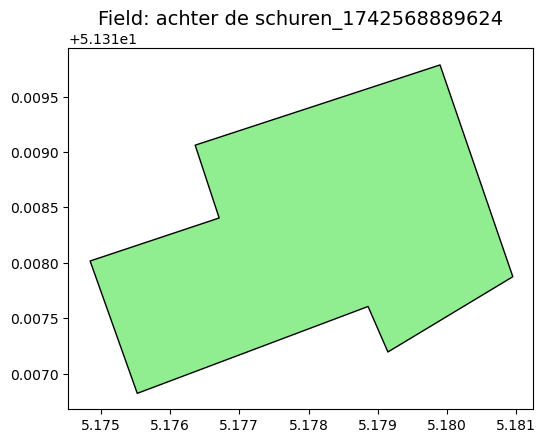

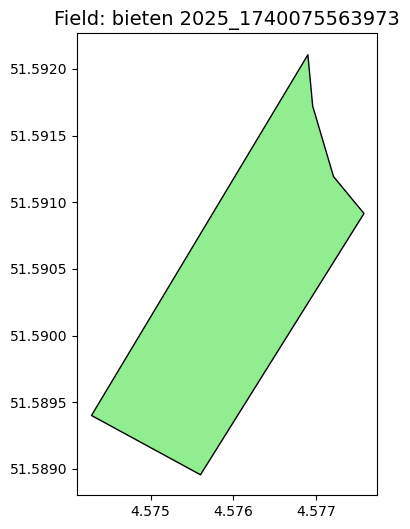

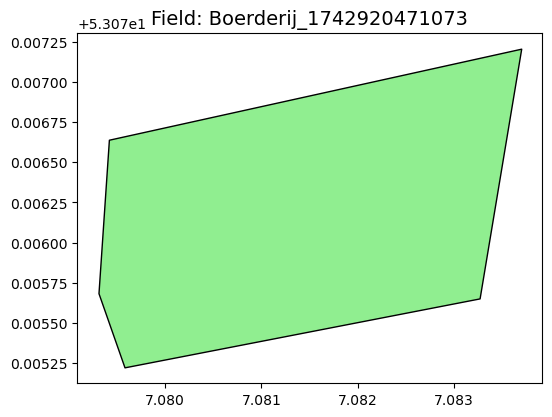

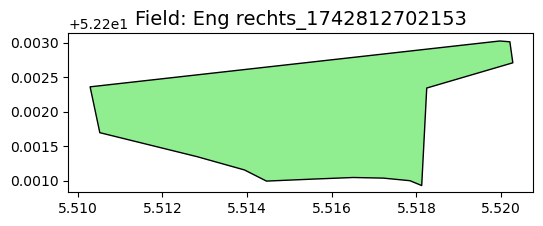

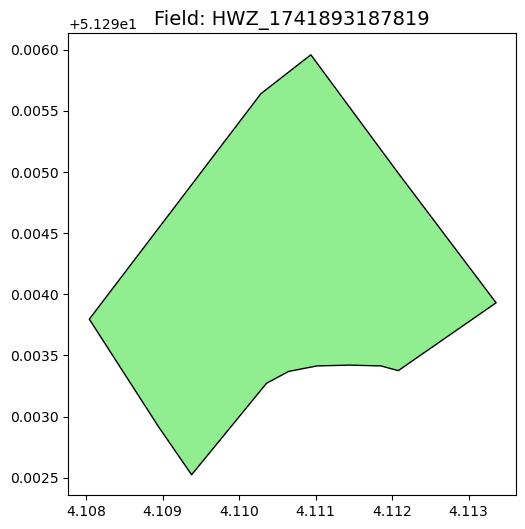

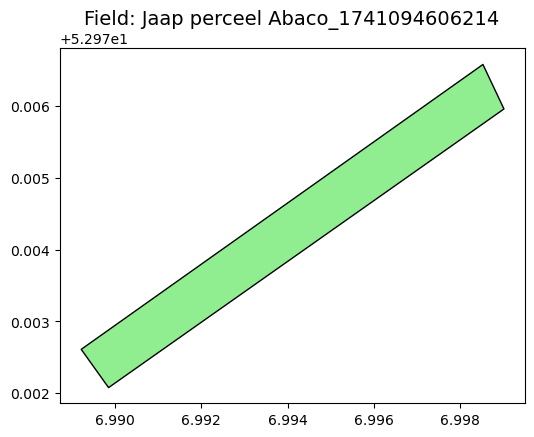

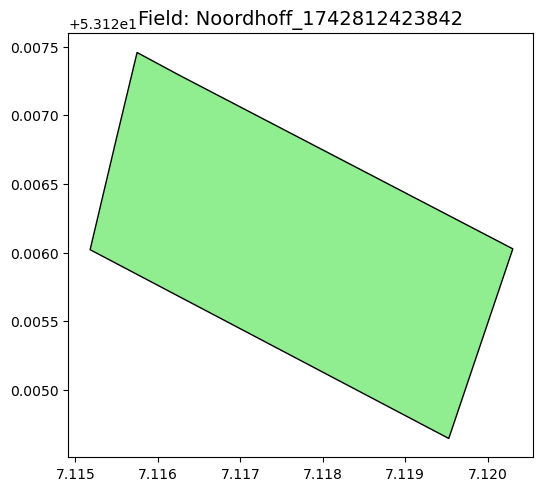

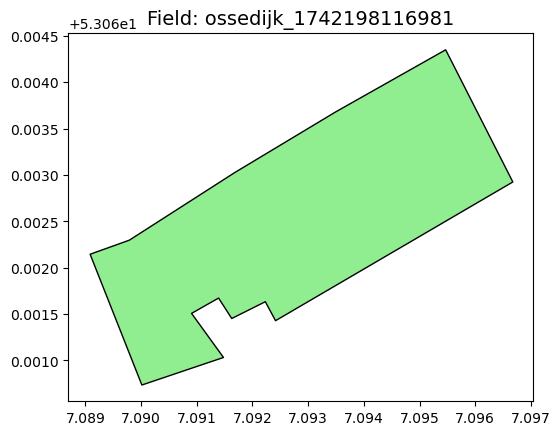

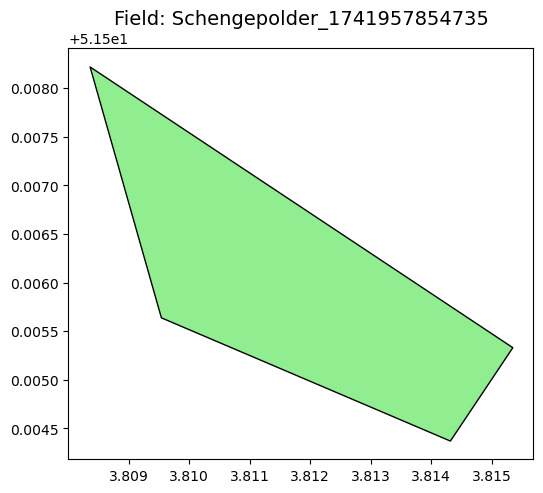

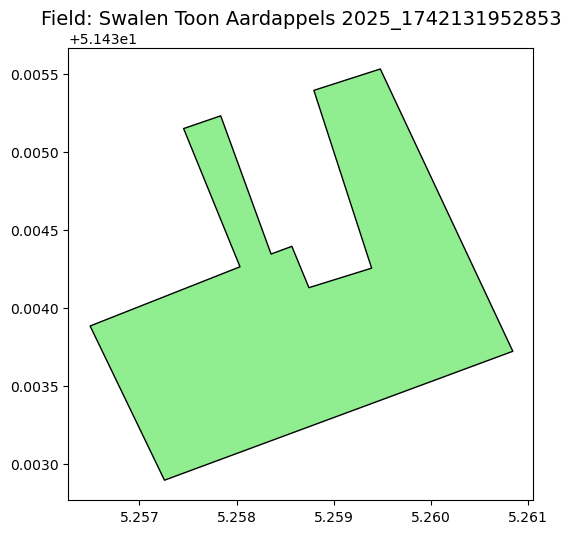

In [12]:
SM_API.output_format = 'gdf'
gdf_fields = SM_API.fields(project_id=project_id)
gdf_fields_subset = gdf_fields.iloc[0:10]
for index, row in gdf_fields_subset.iterrows():
    # Select single row as GeoDataFrame
    gdf_field = gdf_fields_subset.loc[[index]]  # double brackets to keep it as GeoDataFrame

    # Get field name from row (replace 'field_name' with the actual column name)
    field_name = row['name']  
    # Plot
    ax = gdf_field.plot(figsize=(6, 6), edgecolor='black', facecolor='lightgreen')
    ax.set_title(f"Field: {field_name}", fontsize=14)
    plt.show()

In [13]:
gdf_fields["created_at"]

0     2025-03-21T14:54:49.887Z
1     2025-02-20T18:19:24.275Z
2     2025-03-25T16:34:31.305Z
3     2025-03-24T10:38:22.361Z
4     2025-03-13T19:13:08.031Z
5     2025-03-04T13:23:26.479Z
6     2025-03-24T10:33:54.595Z
7     2025-03-17T07:55:17.187Z
8     2025-03-14T13:10:54.970Z
9     2025-03-16T13:32:33.053Z
10    2025-03-16T12:34:46.370Z
Name: created_at, dtype: str

In [14]:
# Select fields for visualization
import pandas as pd

# Convert 'created_at' to datetime (timezone-aware), no format needed
gdf_fields = gdf_fields.copy()
gdf_fields["created_at"] = pd.to_datetime(gdf_fields["created_at"], format="ISO8601", utc=True)

# Calculate centroid for map center (mean of selected fields' centroids)
centroid = gdf_fields.geometry.centroid.union_all().centroid

# Calculate bounds to fit all selected fields
total_bounds = gdf_fields.total_bounds  # [minx, miny, maxx, maxy]
sw = [total_bounds[1], total_bounds[0]]  # (miny, minx)
ne = [total_bounds[3], total_bounds[2]]  # (maxy, maxx)

m = folium.Map(location=[centroid.y, centroid.x], tiles="OpenStreetMap")
m.fit_bounds([sw, ne])

# Add all selected polygons to the map with popups
for idx, row in gdf_fields.iterrows():
    popup_text = "<b>Field Details</b><br>"
    for col in gdf_fields.columns:
        if col == "geometry":
            continue
        popup_text += f"<b>{col}:</b> {row[col]}<br>"
        
    folium.GeoJson(
        row.geometry,
        name=row.name,
        popup=folium.Popup(popup_text, max_width=400)
    ).add_to(m)
m

C:\Users\StevenHoek\AppData\Local\Temp\ipykernel_27400\2309320825.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf_fields.geometry.centroid.union_all().centroid
